In [1]:
import numpy as np
import pandas as pd

import xarray as xr
import xeofs as xe

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

import os  # Para recorrer directorios

from PIL import Image # Para recortar las gráficas y eliminar el exceso de fondo blanco

Creo un nuevo mapa de color para que los datos cercanos a 0 sean completamente blancos

In [2]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

bwr = mpl.colormaps['bwr'].resampled(40)
newcolors = bwr(np.linspace(0, 1, 40))
white = np.array([256/256, 256/256, 256/256, 1])
newcolors[17:23, :] = white
newcmp = ListedColormap(newcolors)

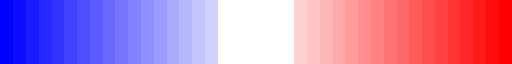

In [3]:
newcmp

# Slice the data depending of the months

In [4]:
def Slice_netcdf(file, months): # hemisph(0=north, 1=south)
    
    ds = xr.open_dataset(file)

    
    hgt = ds['hgt'].values
    time = ds['time'].values
    lon = ds['lon'].values
    lat = ds['lat'].values
    level = ds['level'].values

    years = int(len(time)/12)

    hgt = hgt.reshape((years, 12, 1, 29, 144))

    time = time.reshape((years,12))

    hgt_season = hgt[:, months, :, :, :]  # (años, meses, level, lat, lon)
    time = time[:, months]

    hgt_season = hgt_season.reshape((years * len(months), 29, 144))

    time = time.reshape(years  * len(months))

    HGT = xr.DataArray(
        data=hgt_season,
        dims=["time", "lat", "lon"],
        coords=dict(
            time=time,
            lon=lon,
            lat=lat))

    return HGT

# Calculate the EOF with xeofs

El código para calcular la eof lo obtuve de un ejemplo de la página web de la librería xeofs: https://ajdawson.github.io/eofs/examples/nao_xarray.html https://xeofs.readthedocs.io/en/latest/content/user_guide/auto_examples/1single/plot_weighted-eof.html

Sin embargo en este ejemplo no se calcula la eof como correlación entre los datos y las componentes principales, para lograr eso me apoyé de la herramienta ``ChatGPT``

In [5]:
def Calc_eof(HGT):
    # (4) Based on coslat weighted correlation matrix
    
    model = xe.single.EOF(n_modes=1, standardize=False, use_coslat=True)
    model.fit(HGT, "time")
    
    #PCs
    pcs  = model.scores()            # (time, mode)
    
    # Calcular correlación EOF–PC
    eof_corr = xr.corr(HGT, pcs.isel(mode=0), dim="time")

    return eof_corr

# Slice data for Alta-Baja

In [6]:
def Slice_flux(data, months):

    date = data['Date'].values
    flux = data['flux'].values

    years = int(len(date)/12)

    date = date.reshape((years, 12))

    flux = flux.reshape((years,12))

    date_sliced = date[:, months]  # (años, meses)
    flux = flux[:, months]

    date_sliced = date_sliced.reshape((years * len(months)))
    flux = flux.reshape(years  * len(months))

    flux_sliced = xr.DataArray(
        data=flux,
        dims=["Date"],
        coords=dict(
            Date=date_sliced))

    return flux_sliced

# Plot EOF

El código para graficar la eof lo obtuve de un ejemplo de la página web de la librería eofs: https://ajdawson.github.io/eofs/examples/nao_xarray.html

In [7]:
def Graph_eof(eof, folder, file, months, bias):

    eof = -eof # Invert the sign t be negative in the center in the first months of NAM850
    
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################ Plot the EOF expressed as correlation ########################## 
    clevs = np.linspace(-1, 1, 41)
    
    if ("N" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)    

    elif ("S" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        
    ax = plt.axes(projection=proj)
    ax.coastlines()
    ax.set_global()
    
    eof.plot.contourf(ax=ax, levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=False)

    plt.savefig(f"{folder}/{file}/{bias}-{months}.png")

# Main

# Slice the Flux

In [8]:
flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2025")].reset_index().to_xarray()

# Test

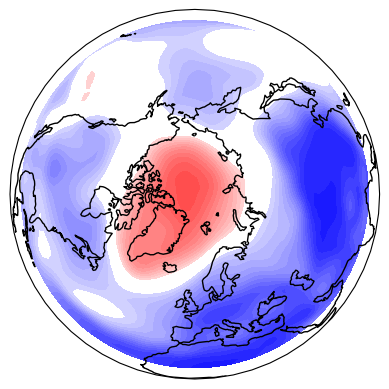

In [9]:
file = "NAMZ850.nc"
month = [7]
flip = False
bias = "Normal"


HGT = Slice_netcdf(f"AMZ/{file}", month)
flux = Slice_flux(flux_data, month)

if bias == "Alta":
    alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
    HGT = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
elif bias == "Baja":
    baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
    HGT = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)

if flip:
    eof = -Calc_eof(HGT)
else:
    eof = Calc_eof(HGT)

#Graph_eof(eof, "Plots", "TestN", f"{file[:-3]}{month}", bias)

# Plot:
if ("N" in file):
    Graph_eof(eof, "Plots", "TestN", f"{file[:-3]}{month}", bias)  

    img = Image.open(f"Plots/TestN/{bias}-{file[:-3]}{month}.png")
    
    # Define the cropping box as a 4-tuple: (left, upper, right, lower)
    # These coordinates represent the top-left (left, upper) and bottom-right (right, lower)
    # corners of the desired crop region.
    
    box = (140, 55, 515, 430)
    
    # Crop the image
    cropped_img = img.crop(box)
    
    # Save the cropped image
    cropped_img.save(f"Plots/TestN/{bias}-{file[:-3]}{month}.png")

elif ("S" in file):
    Graph_eof(eof, "Plots", "TestS", f"{file[:-3]}{month}", bias)


    img = Image.open(f"Plots/TestS/{bias}-{file[:-3]}{month}.png")
    
    # Define the cropping box as a 4-tuple: (left, upper, right, lower)
    # These coordinates represent the top-left (left, upper) and bottom-right (right, lower)
    # corners of the desired crop region.
    
    box = (140, 55, 515, 430)
    
    # Crop the image
    cropped_img = img.crop(box)
    
    # Save the cropped image
    cropped_img.save(f"Plots/TestS/{bias}-{file[:-3]}{month}.png")

## Meses de interés por hemisferio

In [10]:
folder = "Plots"

In [11]:
p_months_north = {"ene-mar":[0,1,2], "jun-ago":[5,6,7]}
p_months_south = {"nov":[10], "jun-ago":[5,6,7], "feb-mar":[1,2]}

### Normal

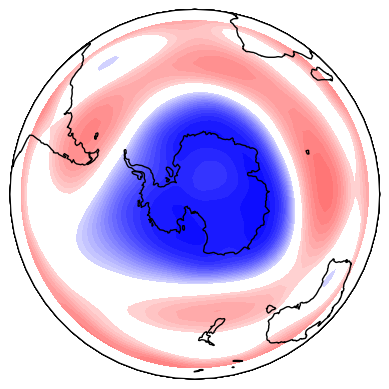

In [12]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

### Alta

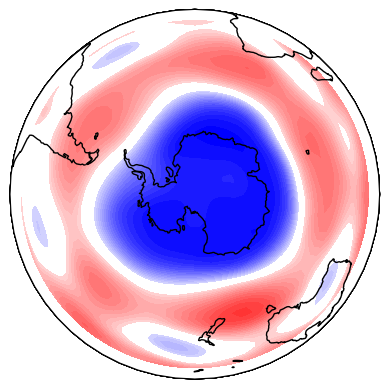

In [13]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

### Baja

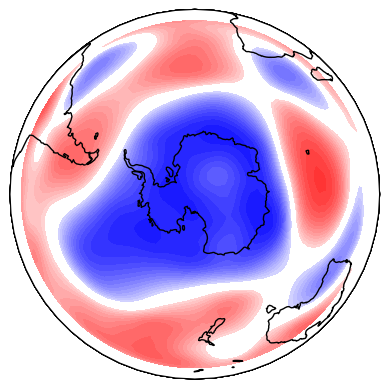

In [14]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

## Recortar imagenes para que sea automático y no tener que recortarlas en Canva

In [15]:
directory = os.scandir("Plots/NAMZ500")

for amz in directory:
    # Open the image
    img = Image.open(f"Plots/NAMZ500/{amz.name}")
    
    # Define the cropping box as a 4-tuple: (left, upper, right, lower)
    # These coordinates represent the top-left (left, upper) and bottom-right (right, lower)
    # corners of the desired crop region.
    
    box = (140, 55, 515, 430)
    
    # Crop the image
    cropped_img = img.crop(box)
    
    # Save the cropped image
    cropped_img.save(f"Plots/NAMZ500/{amz.name}")

directory = os.scandir("Plots/NAMZ850")

for amz in directory:
    img = Image.open(f"Plots/NAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/NAMZ850/{amz.name}")

directory = os.scandir("Plots/SAMZ500")

for amz in directory:
    img = Image.open(f"Plots/SAMZ500/{amz.name}")

    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)

    cropped_img.save(f"Plots/SAMZ500/{amz.name}")

directory = os.scandir("Plots/SAMZ850")

for amz in directory:
    img = Image.open(f"Plots/SAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/SAMZ850/{amz.name}")

# Graficas Mes a Mes

In [16]:
folder = "Plots/Per_Month"

In [23]:
p_months_north = {"ene":[0], "feb":[1], "mar":[2], "abr":[3], "may":[4], "jun":[5], "jul":[6], "ago":[7], "sep":[8], "oct":[9], "nov":[10], "dic":[11]}
p_months_south = {"ene":[0], "feb":[1], "mar":[2], "abr":[3], "may":[4], "jun":[5], "jul":[6], "ago":[7], "sep":[8], "oct":[9], "nov":[10], "dic":[11]}

### Normal

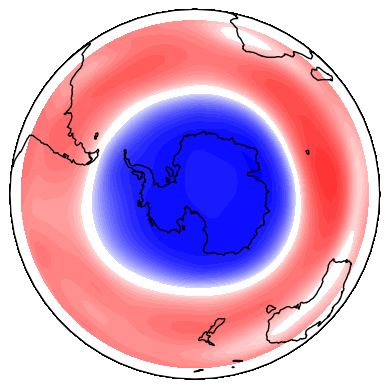

In [18]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

### Alta

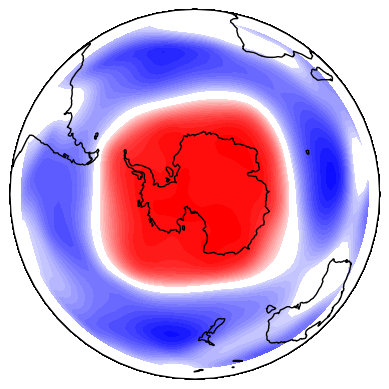

In [19]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

### Baja

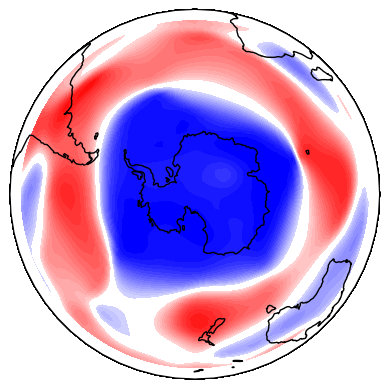

In [20]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            baja = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(baja, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

## Recortar imagenes para que sea automático y no tener que recortarlas en Canva

In [21]:
directory = os.scandir("Plots/Per_Month/NAMZ500")

for amz in directory:
    # Open the image
    img = Image.open(f"Plots/Per_Month/NAMZ500/{amz.name}")
    
    # Define the cropping box as a 4-tuple: (left, upper, right, lower)
    # These coordinates represent the top-left (left, upper) and bottom-right (right, lower)
    # corners of the desired crop region.
    
    box = (140, 55, 515, 430)
    
    # Crop the image
    cropped_img = img.crop(box)
    
    # Save the cropped image
    cropped_img.save(f"Plots/Per_Month/NAMZ500/{amz.name}")

directory = os.scandir("Plots/Per_Month/NAMZ850")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/NAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/Per_Month/NAMZ850/{amz.name}")

directory = os.scandir("Plots/Per_Month/SAMZ500")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/SAMZ500/{amz.name}")

    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)

    cropped_img.save(f"Plots/Per_Month/SAMZ500/{amz.name}")

directory = os.scandir("Plots/Per_Month/SAMZ850")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/SAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/Per_Month/SAMZ850/{amz.name}")

# Create Colorbar

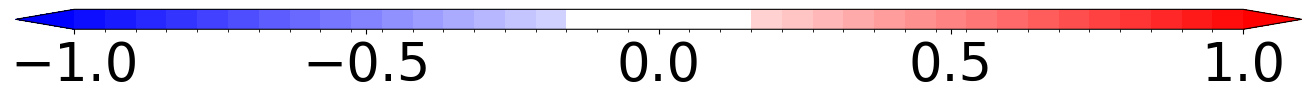

In [22]:
fig, ax = plt.subplots(figsize=(13, 0.9), layout='constrained')

bounds = np.linspace(-1,1, 39)
norm = mpl.colors.BoundaryNorm(bounds, newcmp.N, extend='both')

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm, cmap=newcmp),
             cax=ax, orientation='horizontal')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.ax.tick_params(labelsize=38)
plt.savefig(f"Plots/colorbar_Sur.png")